# DS211 Midterm Lab Exam: Finding the Best Simple Linear Regression Model
**Section DS2A | Sector: Crime | Dataset: `crime_dataset.csv`**

**Group members:**
<br>__Calimpon, Elsie Angela__
<br>__Caralde, Kissaia Mari__
<br>__Jacob, Meckyla Reinne__
<br>__Madorable, Iera Shane__
<br>__Row, Rania Catherine__
<br>__Tesocan, Marie Eugenie__

---
## 1. Real-World Question (Business Problem)

**Scenario.** Our team is a data science unit advising the city's **Social Development Office**, which is launching a new poverty-alleviation livelihood program but can only enroll a limited number of communities in its first year. The office wants to decide *which communities to prioritize*, and is considering violent crime reduction as a secondary benefit worth tracking once the program starts.

**Question.** *How strongly is poverty linked to violent crime across communities, and is that link strong enough to justify using poverty incidence as the primary criterion for selecting which communities enter the program first?*

| | Variable | Meaning |
|---|---|---|
| **Y (outcome)** | `violent_crime_rate_per_1000` | Violent crimes per 1,000 residents |
| **X (predictor)** | `poverty_incidence_pct` | % of residents living below the poverty line |

**Why violent crime?** Of the four outcomes in the data (theft, violent crime, burglary, drug cases), violent crime matters most for residents' safety, and testing its link to poverty gives the Social Development Office a data-backed secondary justification for the program, beyond poverty reduction alone. We deliberately tested the strongest relationship in the dataset (poverty and violent crime) rather than picking a weaker pairing just to seem more original, since a real enrollment decision needs the most defensible evidence available.

## 2. Available Data

In [ ]:
# --- Load the tools (libraries) we need ---
import numpy as np                      # math
import pandas as pd                     # tables
import matplotlib.pyplot as plt         # plots
import seaborn as sns                   # nicer plots
from scipy import stats                 # statistics functions
import statsmodels.api as sm            # regression (OLS)
from statsmodels.stats.diagnostic import het_breuschpagan   # equal-variance test
from statsmodels.stats.stattools import durbin_watson       # independence test

sns.set_style("whitegrid")              # light grid background

# --- Load the data ---
df = pd.read_csv("crime_dataset.csv")   # the CSV must be in the same folder as this notebook
print(df.shape)                         # (rows, columns)
df.head()                               # first 5 rows

(230, 21)


,area_id,area_type,population_density_per_km2,unemployment_rate_pct,poverty_incidence_pct,avg_monthly_income_php,pct_highschool_and_above,streetlights_per_km,cctv_cameras_per_km2,police_officers_per_10000,...,alcohol_outlets_per_km2,park_green_space_pct,avg_household_size,single_parent_household_pct,youth_unemployment_pct,community_program_funding_php_per_capita,reported_theft_cases_per_1000,violent_crime_rate_per_1000,burglary_rate_per_1000,drug_related_cases_per_1000
0,AREA-001,Urban,1900.0,11.4,17.1,27666.0,52.6,10.4,6.1,24.3,...,3.9,16.2,3.5,14.3,32.4,157.0,17.6,7.7,6.3,3.7
1,AREA-002,Suburban,4097.0,15.4,25.6,17955.0,81.4,21.7,0.0,19.0,...,9.0,18.3,4.9,14.5,21.3,35.0,14.5,9.5,8.1,4.7
2,AREA-003,Suburban,4117.0,13.4,20.8,5466.0,69.0,20.5,9.1,15.5,...,7.9,16.8,4.9,11.6,13.4,123.0,14.7,6.9,10.1,5.4
3,AREA-004,Suburban,231.0,10.7,33.1,9637.0,68.6,22.3,5.3,14.9,...,5.4,27.0,4.4,27.0,20.9,0.0,7.6,9.9,14.0,6.9
4,AREA-005,Suburban,774.0,4.0,12.8,21371.0,78.1,16.3,14.8,22.0,...,2.9,33.5,5.3,21.2,8.0,142.0,15.3,3.4,5.6,5.1


In [ ]:
print(df.isna().sum().sum(), "missing values")   # count empty cells
print(df["area_type"].value_counts())            # how many Urban / Suburban / Rural
df.describe().T.round(2)                         # min, max, average of every column

0 missing values
area_type
Urban       105
Suburban     81
Rural        44
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
population_density_per_km2,230.0,1718.42,1521.46,131.0,725.25,1287.00,2116.00,11117.0
unemployment_rate_pct,230.0,12.17,5.16,1.0,8.75,11.90,15.20,29.3
poverty_incidence_pct,230.0,22.22,10.07,2.0,15.82,21.65,28.85,49.7
avg_monthly_income_php,230.0,18132.00,7262.19,4000.0,13249.00,17153.00,22751.50,39815.0
pct_highschool_and_above,230.0,69.12,14.76,22.0,59.55,69.40,79.20,99.0
streetlights_per_km,230.0,18.17,10.26,2.9,10.10,16.50,24.05,55.3
cctv_cameras_per_km2,230.0,8.45,4.93,0.0,5.22,8.10,11.58,21.7
police_officers_per_10000,230.0,14.20,5.08,2.0,10.95,14.50,17.40,26.9
avg_police_response_time_min,230.0,17.64,6.87,3.0,12.52,17.60,22.00,35.2
alcohol_outlets_per_km2,230.0,5.98,4.11,0.4,3.10,4.90,8.48,21.1


**In this table** the data has **230 communities** and **21 columns**, with **no missing values**. There are **4 possible outcomes** (crime rates) and **15 possible predictors** things like poverty, unemployment, streetlights, police response time.

## 3. Variables and Relationships

Using module 1 as reference before choosing, we looked at **all** predictors against **all** outcomes.

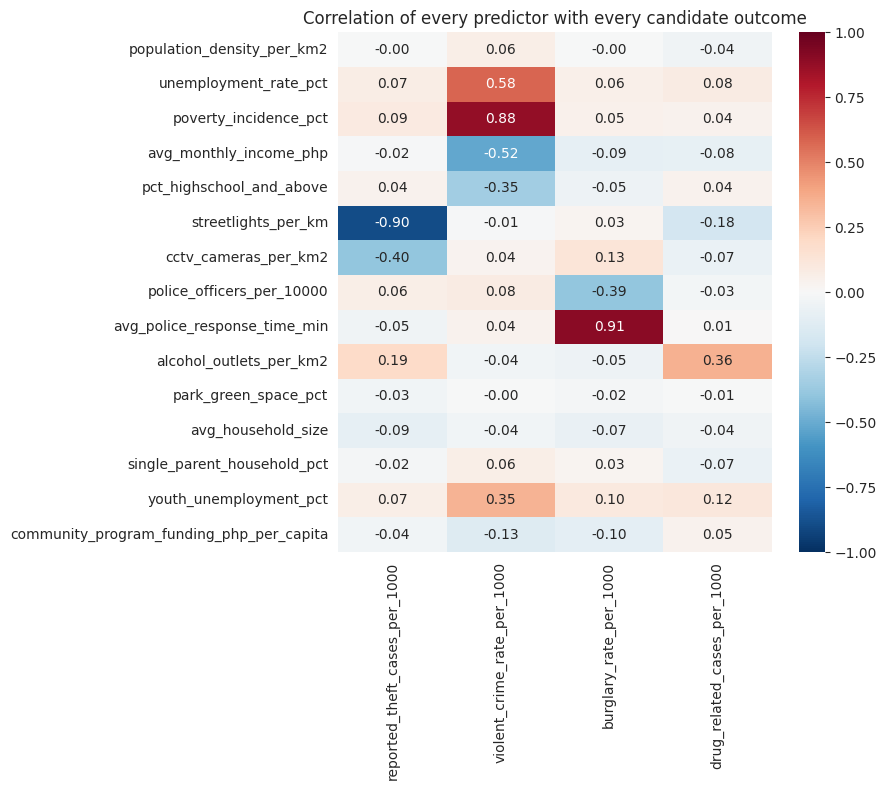

In [ ]:
# These are the 4 possible Y's
outcomes = ["reported_theft_cases_per_1000", "violent_crime_rate_per_1000",
            "burglary_rate_per_1000", "drug_related_cases_per_1000"]

# The 15 possible X's = every column that is not an outcome, ID, or area type
predictors = [c for c in df.columns if c not in outcomes + ["area_id", "area_type"]]

# Correlation of every X with every Y
corr = df[predictors + outcomes].corr().loc[predictors, outcomes]

# Draw it as a colored table (heatmap)
plt.figure(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation of every predictor with every candidate outcome")
plt.tight_layout()
plt.show()

**How to read the heatmap.** Each square is the **correlation (r)** between one predictor (row) and one outcome (column). It goes from **-1 to +1**.
- **Dark red** = strong positive (X goes up, Y goes up).
- **Dark blue** = strong negative (X goes up, Y goes down).
- **White** = no relationship.

**What we see.**
- Theft is strongly tied to **streetlights** (r = -0.90).
- Burglary is strongly tied to **police response time** (r = +0.91).
- **Violent crime is strongly tied to poverty (r = +0.88)**, and moderately to unemployment (+0.58) and income (-0.52).
- Drug cases have no strong predictor.

Each outcome has its own driver, so choosing Y means choosing which problem to solve. We chose **violent crime**.

In [ ]:
Y = "violent_crime_rate_per_1000"       # our chosen outcome

# Fit a quick regression of violent crime on each X, one at a time, and record how well it fits
rows = []
for x in predictors:
    r = stats.linregress(df[x], df[Y])
    rows.append({"predictor": x, "r": r.rvalue, "R2": r.rvalue**2, "p_value": r.pvalue})

# Sort from best fit (highest R2) to worst
ranking = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
ranking.round(4)

,predictor,r,R2,p_value
0,poverty_incidence_pct,0.8812,0.7765,0.0000
1,unemployment_rate_pct,0.5798,0.3362,0.0000
2,avg_monthly_income_php,-0.5222,0.2726,0.0000
3,pct_highschool_and_above,-0.3506,0.1229,0.0000
4,youth_unemployment_pct,0.3464,0.1200,0.0000
5,community_program_funding_php_per_capita,-0.1268,0.0161,0.0548
6,police_officers_per_10000,0.0782,0.0061,0.2375
7,population_density_per_km2,0.0626,0.0039,0.3444
8,single_parent_household_pct,0.0626,0.0039,0.3445
9,avg_police_response_time_min,0.0394,0.0016,0.5524


**In plain words:** this table ranks all 15 predictors by **R²** (how much of the differences in violent crime each one explains). **Poverty is first (R² about 0.78)**, far ahead of the next best, unemployment (about 0.34).

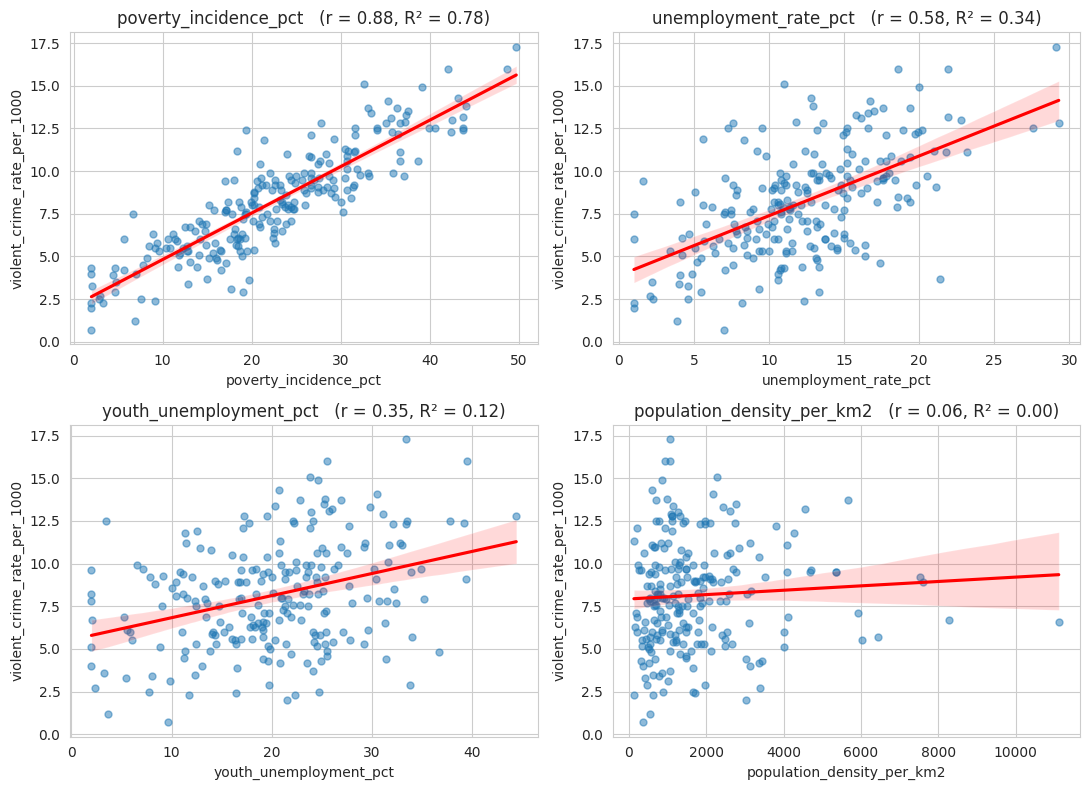

In [ ]:
# Scatterplots for the main candidates
candidates = ["poverty_incidence_pct", "unemployment_rate_pct",
              "youth_unemployment_pct", "population_density_per_km2"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, x in zip(axes.ravel(), candidates):
    r = df[x].corr(df[Y])
    sns.regplot(data=df, x=x, y=Y, ax=ax, scatter_kws={"alpha": 0.5, "s": 25}, line_kws={"color": "red"})
    ax.set_title(f"{x}   (r = {r:.2f}, R² = {r**2:.2f})")
plt.tight_layout()
plt.show()

**How to read a scatterplot.** Each dot is one community. The red line is the best straight line through the dots. The closer the dots hug the line, the stronger the relationship.

**What we see.**
- **Poverty:** dots form a tight upward band around the line, so it is a strong relationship.
- **Unemployment:** upward, but the dots are much more spread out.
- **Youth unemployment:** upward, but very spread out (weak).
- **Population density:** a shapeless cloud with a flat line, so there is **no relationship**.

### Why poverty and not the runner-ups?

| Candidate X | R² | Why set aside |
|---|---|---|
| **Poverty** | **0.78** | **Chosen.** Tight, straight-line pattern |
| Unemployment rate | 0.34 | Real, but explains less than half as much |
| Youth unemployment | 0.12 | Significant but weak; adds nothing when placed next to poverty |
| Population density | 0.00 | No relationship |

## 4. Candidate Model: Simple Linear Regression (Module 2)

$$\text{Violent crime rate} = b_0 + b_1 \times \text{Poverty}$$

In [ ]:
X = sm.add_constant(df["poverty_incidence_pct"])   # add the intercept (b0) to the model
y = df[Y]                                          # the outcome

model = sm.OLS(y, X).fit()                         # fit the best straight line
print(model.summary())                             # full results table

                                 OLS Regression Results                                
Dep. Variable:     violent_crime_rate_per_1000   R-squared:                       0.776
Model:                                     OLS   Adj. R-squared:                  0.775
Method:                          Least Squares   F-statistic:                     791.9
Date:                         Mon, 28 Sep 2026   Prob (F-statistic):           4.03e-76
Time:                                 10:57:43   Log-Likelihood:                -414.71
No. Observations:                          230   AIC:                             833.4
Df Residuals:                              228   BIC:                             840.3
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [ ]:
b0, b1 = model.params    # intercept and slope
print(f"Intercept (b0): {b0:.3f}")
print(f"Slope (b1):     {b1:.4f}   95% CI: {model.conf_int().loc['poverty_incidence_pct'].round(4).tolist()}")
print(f"R-squared:      {model.rsquared:.3f}")
print(f"F-statistic:    {model.fvalue:.1f}   (p = {model.f_pvalue:.2e})")
print(f"Slope p-value:  {model.pvalues['poverty_incidence_pct']:.2e}")
print(f"Typical error (RMSE): {np.sqrt(model.mse_resid):.2f} crimes per 1,000")

Intercept (b0): 2.101
Slope (b1):     0.2722   95% CI: [0.2532, 0.2913]
R-squared:      0.776
F-statistic:    791.9   (p = 4.03e-76)
Slope p-value:  4.03e-76
Typical error (RMSE): 1.47 crimes per 1,000


### What the results mean

| Result | Value | Plain-language meaning |
|---|---|---|
| **Slope** | about 0.272 | For every **+1 percentage point** of poverty, violent crime goes up by about **0.27 per 1,000 residents**. A 10-point gap is about 2.7 more. |
| **Intercept** | about 2.10 | The line's starting point (predicted rate at 0% poverty). Our data starts near 2% poverty, so treat it as an anchor, not a real prediction. |
| **R²** | about 0.78 | Poverty alone explains about **78%** of the differences in violent crime between communities. The other 22% is due to things not in the model. |
| **F-test (p about 0)** | F about 792 | The model as a whole is significant (much better than guessing the average). |
| **Slope p-value (about 0)** | far below 0.05 | Poverty is a statistically significant predictor; this is not a fluke. |
| **95% CI** | about 0.25 to 0.29 | The true slope is very likely in this narrow range, and it does not include 0. |
| **Typical error** | about 1.47 | Predictions are usually off by about 1.5 crimes per 1,000 (average rate is about 8.1). |

**Example:** at 30% poverty, predicted violent crime = 2.10 + 0.272 x 30 = about **10.27 per 1,000**.

## 5. Model Checking: LINE Assumptions (Module 3)

The results above are only trustworthy if the model's mistakes behave well. A **residual** is the mistake for one community: **actual minus predicted**. We check four things, called **LINE**:

| Letter | Assumption | Plain meaning |
|---|---|---|
| **L** | Linearity | The relationship is really a straight line, not a curve |
| **I** | Independence | One community's mistake does not predict the next one's |
| **N** | Normality | The mistakes are roughly bell-shaped |
| **E** | Equal variance | The mistakes are about the same size everywhere |

In [ ]:
fitted = model.fittedvalues   # what the line predicted for each community
resid = model.resid           # the mistakes (actual - predicted)

### L and E: Linearity and Equal variance (one plot checks both)

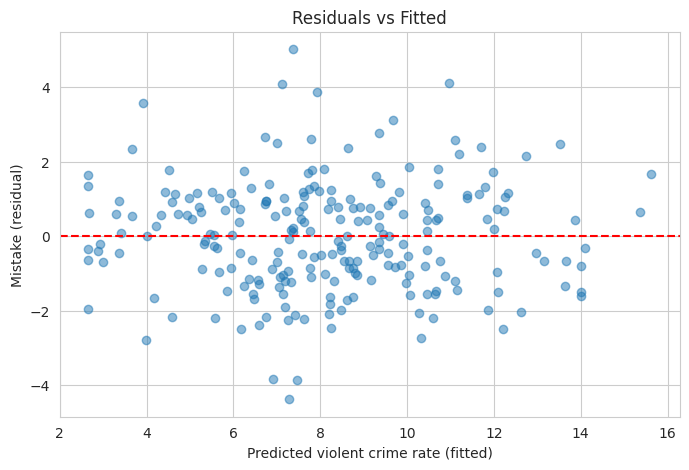

Breusch-Pagan test: p = 0.868


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.5)            # each dot = one community's mistake
plt.axhline(0, color="red", linestyle="--")      # the zero line = no mistake
plt.xlabel("Predicted violent crime rate (fitted)")
plt.ylabel("Mistake (residual)")
plt.title("Residuals vs Fitted")
plt.show()

# Breusch-Pagan test for equal variance
bp_lm, bp_p, _, _ = het_breuschpagan(resid, model.model.exog)
print(f"Breusch-Pagan test: p = {bp_p:.3f}")

**How to read it.** Each dot is one community's mistake. We want a **random cloud around the zero line**.
- If the dots make a **curve** (U-shape or hump), the relationship is not straight (Linearity fails).
- If the dots make a **funnel** (narrow on one side, wide on the other), the mistakes are not equal in size (Equal variance fails).

**What we see.** A random, even cloud: no curve and no funnel.

**Breusch-Pagan test:** p is about **0.87**. Here a **big p-value is good** (above 0.05 means we found no evidence of unequal variance).

**Verdict: L holds, E holds.**

### I: Independence

Durbin-Watson: 1.947   (about 2 = good)


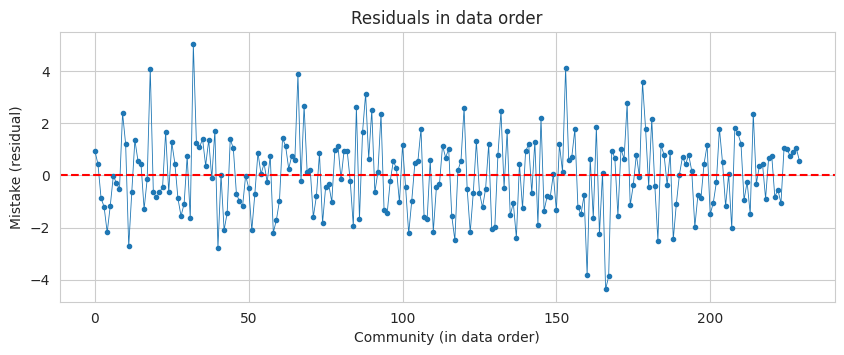

In [ ]:
dw = durbin_watson(resid)
print(f"Durbin-Watson: {dw:.3f}   (about 2 = good)")

plt.figure(figsize=(10, 3.5))
plt.plot(resid.values, marker="o", markersize=3, linewidth=0.6)   # mistakes in data order
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Community (in data order)")
plt.ylabel("Mistake (residual)")
plt.title("Residuals in data order")
plt.show()

**How to read it.** The **Durbin-Watson** number goes from 0 to 4, and **about 2 means no pattern** in the mistakes. The plot should look like random ups and downs, with no long streaks above or below zero.

**What we see.** Durbin-Watson is about **1.95**, very close to 2, and the plot has no streaks.

**Verdict: I holds.** *Honest caveat:* our data is a single snapshot of many communities. If neighboring communities influence each other, independence could still be broken, and we have no location data to test that.

### N: Normality

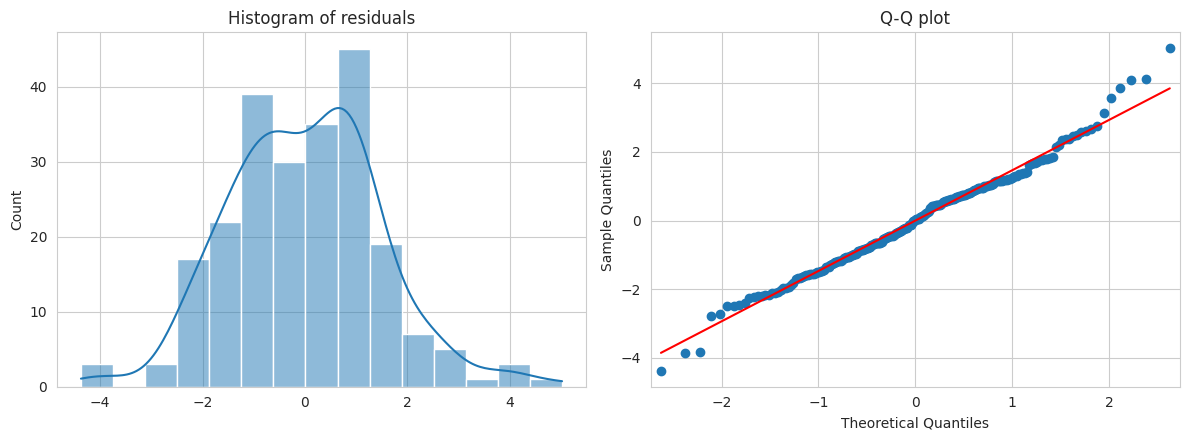

Shapiro-Wilk test: p = 0.110


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(resid, kde=True, ax=axes[0])        # histogram of the mistakes
axes[0].set_title("Histogram of residuals")

sm.qqplot(resid, line="s", ax=axes[1])           # Q-Q plot: compare mistakes to a perfect bell curve
axes[1].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(resid)             # Shapiro-Wilk normality test
print(f"Shapiro-Wilk test: p = {sw_p:.3f}")

**How to read it.**
- **Histogram:** we want a **bell shape**.
- **Q-Q plot:** we want the dots **on the diagonal line**. Dots curving far away at the ends mean the mistakes are not normal.
- **Shapiro-Wilk test:** a **big p-value (above 0.05) is good**, because it means we found no evidence against normality.

**What we see.** A bell-shaped histogram, dots on the line, and p about **0.11** (above 0.05).

**Verdict: N holds.**

### LINE summary

| Assumption | Check | Result |
|---|---|---|
| **L**inearity | Residuals vs fitted plot | Holds (no curve) |
| **I**ndependence | Durbin-Watson about 1.95, order plot | Holds (spatial dependence cannot be tested) |
| **N**ormality | Histogram, Q-Q plot, Shapiro-Wilk p about 0.11 | Holds |
| **E**qual variance | Residuals vs fitted plot, Breusch-Pagan p about 0.87 | Holds |

All four assumptions look reasonable, so the OLS results (slope, p-values, F-test) can be trusted **as a description of the pattern in this dataset**.

## 6. Interpretation

- Communities with higher poverty tend to have higher violent crime. **Each extra percentage point of poverty goes with about 0.27 more violent crimes per 1,000 residents.**
- Poverty alone explains about **78%** of the differences in violent crime between the 230 communities, which is strong for a one-variable model.
- The relationship is statistically significant and the model passes all four LINE checks.
- **This shows association, not cause.** We cannot say poverty *causes* violence; other factors could affect both.
- The model should only be used for poverty levels within the data range (about 2% to 50%).

## 7. Recommendation

**For the Social Development Office:** poverty incidence is a strong, statistically reliable indicator (R² = 0.78) of a community's violent crime rate, and can be used as the **primary criterion for selecting which communities enroll first** in the livelihood program. Communities with the highest poverty rates should be prioritized, both to address poverty directly and because they are also where violent crime rates are highest.

**Important scope of this recommendation:** the model shows a strong *association*, not a proven cause. We are **not** claiming that enrolling a community will lower its violent crime rate — only that poverty and violent crime move together closely enough to make poverty a defensible targeting criterion. If the office wants to claim the program will also reduce crime, that would need to be tracked and tested directly once the program launches, not assumed from this model alone.

**Before fully trusting the model for enrollment decisions, we would still want to know:**
1. Does the relationship hold over time, or is this a one-time snapshot? (we only have one snapshot, so we can't confirm poverty comes *before* the crime, only that they move together)
2. Do neighboring communities influence each other? (possible spatial dependence we cannot test with this data)
3. What explains the other 22%? (adding more predictors is beyond simple regression, but could sharpen targeting further)
4. Once the program launches, does violent crime actually fall in enrolled communities? (this is the real causal test, and should be tracked going forward)